In [ ]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from lightgbm.sklearn import LGBMRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.metrics import mean_squared_error

from mlxtend.regressor import StackingCVRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer


In [ ]:
df = pd.read_csv('roboBohr.csv')


In [ ]:
df.head()

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,1267,1268,1269,1270,1271,1272,1273,1274,pubchem_id,Eat
0,0,73.516695,17.817765,12.469551,12.458130,12.454607,12.447345,12.433065,12.426926,12.387474,...,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,25004,-19.013763
1,1,73.516695,20.649126,18.527789,17.891535,17.887995,17.871731,17.852586,17.729842,15.864270,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25005,-10.161019
2,2,73.516695,17.830377,12.512263,12.404775,12.394493,12.391564,12.324461,12.238106,10.423249,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25006,-9.376619
3,3,73.516695,17.875810,17.871259,17.862402,17.850920,17.850440,12.558105,12.557645,12.517583,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25009,-13.776438
4,4,73.516695,17.883818,17.868256,17.864221,17.818540,12.508657,12.490519,12.450098,10.597068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25011,-8.537140


In [ ]:
print(df.shape)


(16242, 1278)


In [ ]:
df.isnull().sum().sum()

0

In [ ]:
df.columns


Index(['Unnamed: 0', '0', '1', '2', '3', '4', '5', '6', '7', '8',
       ...
       '1267', '1268', '1269', '1270', '1271', '1272', '1273', '1274',
       'pubchem_id', 'Eat'],
      dtype='object', length=1278)

In [ ]:
df = df.drop(['Unnamed: 0', 'pubchem_id'], axis = 1)


In [ ]:
df.Eat.describe()

count    16242.000000
mean       -11.178969
std          3.659133
min        -23.245373
25%        -13.475805
50%        -10.835211
75%         -8.623903
max         -0.789513
Name: Eat, dtype: float64

/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


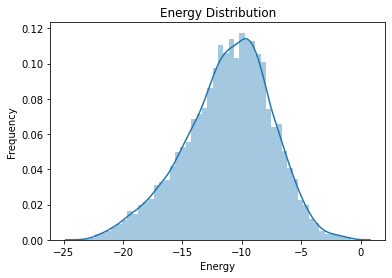

In [ ]:
sns.distplot(df['Eat'], kde=True)
plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy Distribution');

In [ ]:
df_new = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/coulombL.csv', header=None, index_col=0)


In [ ]:
df_new = pd.read_csv('coulombL.csv',header=None, index_col=0)

pca = PCA(n_components=2)
pca_model = pca.fit_transform(df_new)
pca_model = pd.DataFrame(pca_model)

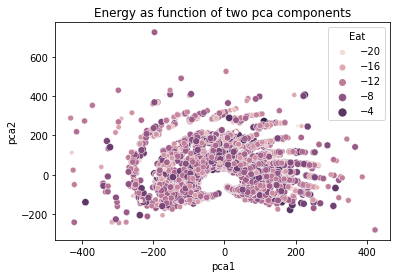

In [ ]:
sns_plot = sns.cubehelix_palette(light=1, as_cmap=True)
ax = sns.scatterplot(x=-pca_model[0], y=pca_model[1],
                     size=df.Eat,hue=df.Eat,
                     palette=sns_plot, sizes=(10, 60))
plt.xlabel('pca1')
plt.ylabel('pca2')
plt.title('Energy as function of two pca components');

In [ ]:
Y = df['Eat']
df = df.drop(['Eat'], axis = 1)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(df, Y, test_size=0.25)

In [ ]:
lgbm_model = LGBMRegressor(num_leaves = 20, n_estimators = 200, min_child_weight = 7, max_depth = 5, learning_rate = 0.1,
                           colsample_bytree = 0.3)

xgb_model = XGBRegressor(objective='reg:linear', eval_metric = 'rmse', learning_rate = 0.0625, reg_lambda = 0,
                         max_depth = 5, colsample_bytree = 0.1, min_child_weight = 12, n_estimators = 500)
rf_model = RandomForestRegressor(n_estimators = 125, min_samples_split = 5, max_features = 'auto', max_depth = 5)
knn_model = KNeighborsRegressor(weights = 'distance', n_neighbors = 5, leaf_size = 100)
ridge_model = Ridge(alpha = 800)
lasso_model = Lasso(alpha = 0.05, max_iter=8000)


In [ ]:
class Regressor_Average_Score(BaseEstimator, RegressorMixin, TransformerMixin):
    def __init__(self, reg):
        self.reg = reg
        self.predict = None

    def fit(self, X, y):
        for regs in self.reg:
            regs.fit(X, y)
        return self

    def predict(self, X):
        self.predict = np.column_stack([regs.predict(X) for regs in self.reg])
        return np.mean(self.predict, axis=1)
    
    
averaged_model = Regressor_Average_Score([xgb_model, lgbm_model])

[08:30:58] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[08:31:48] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[08:32:38] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[08:33:30] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[08:34:21] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[08:37:11] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[08:38:08] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[08:39:07] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of re

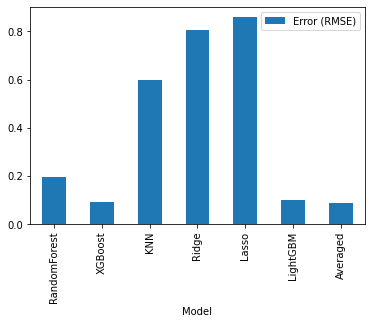

In [ ]:
def root_mean_square(predicted, actual):
    return np.sqrt(np.mean(np.square(predicted - actual)))

rmse = make_scorer(root_mean_square, greater_is_better=False)

models = [
     ('RandomForest', rf_model),
     ('XGBoost', xgb_model),
     ('KNN', knn_model),
     ('Ridge', ridge_model),
     ('Lasso', lasso_model),
     ('LightGBM', lgbm_model),
     ('Averaged', averaged_model),
]

scores = [
    -1.0 * cross_val_score(model, x_train.values, y_train.values, scoring=rmse, cv=5).mean()
    for _,model in models
]

df_new = pd.DataFrame({ 'Model': [name for name, _ in models], 'Error (RMSE)': scores })
df_new.plot(x='Model', kind='bar')

In [ ]:
df_new

,Model,Error (RMSE)
0,RandomForest,0.195093
1,XGBoost,0.090946
2,KNN,0.600281
3,Ridge,0.807118
4,Lasso,0.859679
5,LightGBM,0.099845
6,Averaged,0.088244


In [ ]:
averaged_model.fit(x_train, y_train)
y_pred_avg = averaged_model.predict(x_test)
print("RMSE Value for testing Averaged model (xgb + lgb) is "
          +str(np.sqrt(mean_squared_error(y_test, y_pred_avg))))

[09:19:14] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
RMSE Value for testing Averaged model (xgb + lgb) is 0.08548309692940105


In [ ]:
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
print("RMSE Value for testing XGB model is "
          +str(np.sqrt(mean_squared_error(y_test, y_pred_xgb))))

[09:20:29] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
RMSE Value for testing XGB model is 0.08738262585311009


In [ ]:
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
print("RMSE Value for testing Random Forest model is "
            +str(np.sqrt(mean_squared_error(y_test, y_pred_rf))))

RMSE Value for testing Random Forest model is 0.2001663493447642


In [ ]:
lgbm_model.fit(x_train, y_train)
y_pred_lgbm = lgbm_model.predict(x_test)
print("RMSE Value for testing LightGBM model is "
          +str(np.sqrt(mean_squared_error(y_test, y_pred_lgbm))))

RMSE Value for testing LightGBM model is 0.09719250888816772


In [ ]:
print('XGBoost model test mean: %.3f' % y_pred_xgb.mean())
print('lgbm model test mean: %.3f' % y_pred_lgbm.mean())
print('Averaged model Test mean: %.3f' % y_pred_avg.mean())
print('Random Forest mean: %.3f' % y_pred_rf.mean())
print('Test mean: %.3f' % y_test.mean())

XGBoost model test mean: -11.214
lgbm model test mean: -11.214
Averaged model Test mean: -11.214
Random Forest mean: -11.211
Test mean: -11.212


/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)
/usr/local/lib/python3.8/dist-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function 

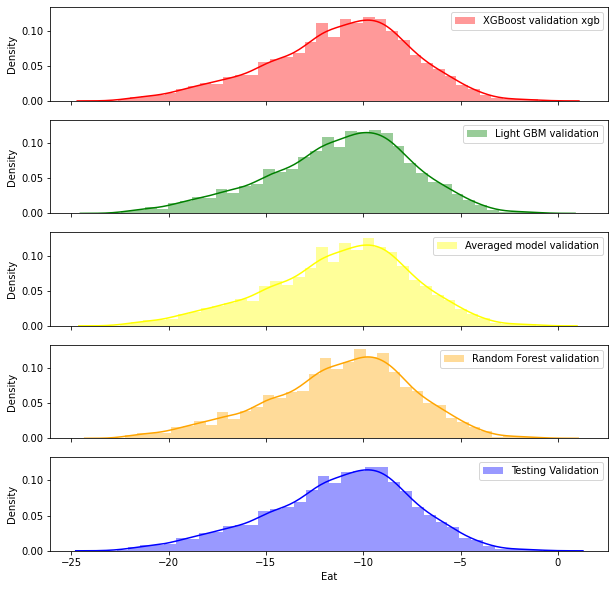

In [ ]:
fig, ax = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(10,10))
sns.distplot(y_pred_xgb, ax=ax[0], color='red', label='XGBoost validation xgb')
sns.distplot(y_pred_lgbm, ax=ax[1], color='green', label='Light GBM validation')
sns.distplot(y_pred_avg, ax=ax[2], color='yellow', label='Averaged model validation')
sns.distplot(y_pred_rf, ax=ax[3], color='orange', label='Random Forest validation')
sns.distplot(y_test, ax=ax[4], color='blue', label='Testing Validation')

ax[0].legend(loc=0)
ax[1].legend(loc=0)
ax[2].legend(loc=0)
ax[3].legend(loc=0)
ax[4].legend(loc=0)
plt.show()